© 2026 WaLSA Team - Shahin Jafarzadeh et al.

This notebook is part of the [WaLSAlib](https://github.com/WaLSAteam/WaLSAlib) package (v1.0.0), provided under the [Apache License, Version 2.0](http://www.apache.org/licenses/LICENSE-2.0).

You may use, modify, and distribute this notebook and its contents under the terms of the license.

---

**Important Note on Figures**:
Figures generated using this notebook that are **identical to or derivative of those published in**:  
**Jafarzadeh, S., Jess, D. B., Stangalini, M. et al. 2026, *Frontiers in Astronomy and Space Sciences*, in prep.**,  
as part of the research topic: **[Magnetohydrodynamic Motions: Daniel K. Inouye Solar Telescope’s Window into the Dynamic Sun](https://www.frontiersin.org/research-topics/71781/magnetohydrodynamic-motions-daniel-k-inouye-solar-telescopes-window-into-the-dynamic-sun)**,    
are copyrighted by ***Frontiers in Astronomy and Space Sciences***. Any reuse of such figures requires explicit permission from the journal.   

Figures that are newly created, modified, or unrelated to the published article may be used under the terms of the Apache License.

---

**Disclaimer**:
This notebook and its code are provided "as is", without warranty of any kind, express or implied. Refer to the license for more details.

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure 4 — Calculations (Refined Global Wavelet Spectra - RGWS)
================================================================

Purpose
-------
Compute and cache the wavelet-based Refined Global Wavelet Spectra (RGWS) used in
Figure 4, for multiple selected lines, for:

  • Truth velocities                  (v_true)
  • LineFit velocities                (v_linefit)
  • Fast estimators:
      - Parabolic minimum             (v_parab)
      - Centre-of-gravity (COG)       (v_cog)
      - Fourier-phase centroid (k=1)  (v_fft)
      - Weighted polynomial core fit  (v_poly)   ("Poly6w")

This script:
  1) Loads the Figure-3 cached velocity time series from:   Files/Fig3_cache/
  2) Runs WaLSAtools wavelet analysis per selected line and per method
  3) Interpolates all spectra onto the Truth period grid (for direct comparison)
  4) Saves a small cache per line under:                    Files/Fig4_cache/

Important: No changes to calculations
-------------------------------------
This is intentionally a "cache builder" only. It does not modify the underlying
analysis logic. In particular:
  • The exact WaLSAtools call signature is preserved.
  • Detrend+apodisation is applied via WaLSA_detrend_apod exactly as required:
        v_signal_apod = WaLSA_detrend_apod(v_signal, apod=0.10, silent=True)
  • WaLSAtools is called with:
        method="wavelet", GWS=True, RGWS=True, siglevel=0.95, mother="morlet"
  • Any interpolation is purely for aligning grids for plotting, not altering spectra.

Inputs
------
Required (from Figure 3 cache, produced by "Figure 3 — Calculations"):
  Files/Fig3_cache/fig3_vtimeseries__t_s.npy
  Files/Fig3_cache/fig3_vtimeseries__v_true.npy
  Files/Fig3_cache/fig3_vtimeseries__v_linefit.npy
  Files/Fig3_cache/fig3_vtimeseries__v_parab.npy
  Files/Fig3_cache/fig3_vtimeseries__v_cog.npy
  Files/Fig3_cache/fig3_vtimeseries__v_fft.npy
  Files/Fig3_cache/fig3_vtimeseries__v_poly.npy
  Files/Fig3_cache/fig3_vtimeseries__meta.npz

Outputs
-------
Per selected line index i (0-based), saved under Files/Fig4_cache/ with tag:

  fig4_waveletGWS_multiline__line{i}__f_mhz.npy
  fig4_waveletGWS_multiline__line{i}__periods_s.npy
  fig4_waveletGWS_multiline__line{i}__P_truth.npy
  fig4_waveletGWS_multiline__line{i}__P_linefit.npy
  fig4_waveletGWS_multiline__line{i}__P_parab.npy
  fig4_waveletGWS_multiline__line{i}__P_cog.npy
  fig4_waveletGWS_multiline__line{i}__P_fft.npy
  fig4_waveletGWS_multiline__line{i}__P_poly.npy
  (and the corresponding ratios R_* = P_*/P_truth)
  fig4_waveletGWS_multiline__line{i}__meta.npz

Notes
-----
• "LineFit" here refers to the WaLSAlib implementation accessed as `linefit`
  in the paper; the cached velocity series is stored as v_linefit.npy.
• This script is designed to be run after Figure 3 cache exists.

Dependencies
------------
numpy
WaLSAtools (WaLSAtools, WaLSA_detrend_apod)

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

from __future__ import annotations

import os
import numpy as np

from WaLSAtools import WaLSAtools, WaLSA_detrend_apod  # type: ignore


# =============================================================================
# USER SETTINGS
# =============================================================================

# --- Figure-3 cache (inputs) ---
FIG3_CACHE_DIR = "Files/Fig3_cache"
FIG3_CACHE_TAG = "fig3_vtimeseries"

# --- Lines to compute RGWS for (0-based line indices) ---
LINE_INDICES = [3, 5]

# --- Wavelet/RGWS settings (must match paper text) ---
APOD     = 0.10
SIGLEVEL = 0.95
MOTHER   = "morlet"

# --- Figure-4 cache (outputs) ---
FIG4_CACHE_DIR = "Files/Fig4_cache"
FIG4_CACHE_TAG = "fig4_waveletGWS_multiline"


# =============================================================================
# LOAD FIGURE-3 CACHE (velocity time series)
# =============================================================================

# Time axis (seconds)
t_s = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__t_s.npy"))

# Velocity matrices: shape (nt, n_lines)
v_true    = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__v_true.npy"))
v_linefit = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__v_linefit.npy"))

v_parab   = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__v_parab.npy"))
v_cog     = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__v_cog.npy"))
v_fft     = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__v_fft.npy"))
v_poly    = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__v_poly.npy"))

# Meta tells us whether LineFit series was actually computed/available in the cache
meta = np.load(os.path.join(FIG3_CACHE_DIR, f"{FIG3_CACHE_TAG}__meta.npz"), allow_pickle=True)

# Backwards-compatible key handling:
# - new: RUN_LINEFIT_TIMESERIES
# - legacy: RUN_WALSA_TIMESERIES
if "RUN_LINEFIT_TIMESERIES" in meta.files:
    RUN_LINEFIT_TIMESERIES = bool(meta["RUN_LINEFIT_TIMESERIES"])
elif "RUN_WALSA_TIMESERIES" in meta.files:
    RUN_LINEFIT_TIMESERIES = bool(meta["RUN_WALSA_TIMESERIES"])
else:
    # If not present, default to True (since v_linefit.npy exists if we got here)
    RUN_LINEFIT_TIMESERIES = True

nt, n_lines = v_true.shape

# Basic sanity checks (non-fatal, but helpful)
if v_linefit.shape != (nt, n_lines):
    raise ValueError(f"v_linefit has shape {v_linefit.shape}, expected {(nt, n_lines)}")
for name, arr in [("v_parab", v_parab), ("v_cog", v_cog), ("v_fft", v_fft), ("v_poly", v_poly)]:
    if arr.shape != (nt, n_lines):
        raise ValueError(f"{name} has shape {arr.shape}, expected {(nt, n_lines)}")


# =============================================================================
# HELPERS
# =============================================================================

def _get_line(vmat: np.ndarray, i_line: int) -> np.ndarray:
    """Return 1D velocity time series for a given line index (float)."""
    return np.asarray(vmat[:, i_line], dtype=float)


def _wavelet_gws_power(v_signal: np.ndarray, times: np.ndarray, apod: float = 0.10) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute RGWS power using WaLSAtools, returning:
      - periods_s : 1D array of periods (seconds)
      - power     : 1D array of RGWS power (same length)

    IMPORTANT: This keeps the exact calling pattern required for the paper.
    """
    # Required form (paper consistency)
    v_signal_apod = WaLSA_detrend_apod(v_signal, apod=apod, silent=True)

    out = WaLSAtools(
        signal=v_signal_apod,
        time=times,
        method="wavelet",
        siglevel=SIGLEVEL,
        apod=apod,
        mother=MOTHER,
        GWS=True,
        RGWS=True,
        cadence=float(np.nanmedian(np.diff(times))),
        silent=False,          
        nodetrendapod=True,    # since we already detrended+apodised
    )

    periods_s = np.asarray(out[1], dtype=float)
    power     = np.asarray(out[-1], dtype=float)

    return periods_s, power


def _interp_to(periods_src: np.ndarray, P_src: np.ndarray, periods_ref: np.ndarray) -> np.ndarray:
    """
    Interpolate P(period) onto a reference period grid.
    NaN-safe; returns NaNs if insufficient valid samples exist.
    """
    periods_src = np.asarray(periods_src, dtype=float)
    P_src       = np.asarray(P_src,       dtype=float)
    periods_ref = np.asarray(periods_ref, dtype=float)

    m = np.isfinite(periods_src) & np.isfinite(P_src)
    if np.count_nonzero(m) < 2:
        return np.full_like(periods_ref, np.nan, dtype=float)

    x = periods_src[m]
    y = P_src[m]
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    return np.interp(periods_ref, x, y, left=np.nan, right=np.nan)


# =============================================================================
# MAIN LOOP: compute per-line caches
# =============================================================================

times = np.asarray(t_s, dtype=float)
os.makedirs(FIG4_CACHE_DIR, exist_ok=True)

for i_line in LINE_INDICES:
    if not (0 <= int(i_line) < n_lines):
        raise ValueError(f"Requested line index {i_line} is out of range [0, {n_lines-1}]")

    print(f"\nComputing Figure-4 cache for line index {i_line} ...")

    # -------------------------------------------------------------------------
    # Truth defines the reference period grid (for consistent interpolation)
    # -------------------------------------------------------------------------
    periods_truth_s, P_truth = _wavelet_gws_power(_get_line(v_true, i_line), times, apod=APOD)

    # -------------------------------------------------------------------------
    # Fast methods: compute their RGWS and interpolate onto Truth periods
    # -------------------------------------------------------------------------
    periods_parab_s, P_parab_raw = _wavelet_gws_power(_get_line(v_parab, i_line), times, apod=APOD)
    periods_cog_s,   P_cog_raw   = _wavelet_gws_power(_get_line(v_cog,   i_line), times, apod=APOD)
    periods_fft_s,   P_fft_raw   = _wavelet_gws_power(_get_line(v_fft,   i_line), times, apod=APOD)
    periods_poly_s,  P_poly_raw  = _wavelet_gws_power(_get_line(v_poly,  i_line), times, apod=APOD)

    P_parab = _interp_to(periods_parab_s, P_parab_raw, periods_truth_s)
    P_cog   = _interp_to(periods_cog_s,   P_cog_raw,   periods_truth_s)
    P_fft   = _interp_to(periods_fft_s,   P_fft_raw,   periods_truth_s)
    P_poly  = _interp_to(periods_poly_s,  P_poly_raw,  periods_truth_s)

    # -------------------------------------------------------------------------
    # LineFit: compute if present (cache should contain v_linefit regardless),
    # but keep gating in case meta says it is not available.
    # -------------------------------------------------------------------------
    if RUN_LINEFIT_TIMESERIES:
        periods_linefit_s, P_linefit_raw = _wavelet_gws_power(_get_line(v_linefit, i_line), times, apod=APOD)
        P_linefit = _interp_to(periods_linefit_s, P_linefit_raw, periods_truth_s)
    else:
        P_linefit = np.full_like(P_truth, np.nan, dtype=float)

    # -------------------------------------------------------------------------
    # Convert periods -> frequency in mHz
    # -------------------------------------------------------------------------
    f_mhz = 1e3 / periods_truth_s

    # -------------------------------------------------------------------------
    # Ratios vs truth (kept in cache even if not plotted now)
    # -------------------------------------------------------------------------
    eps = 1e-30
    P_truth_safe = np.where(np.isfinite(P_truth) & (P_truth > 0), P_truth, eps)

    R_parab   = P_parab   / P_truth_safe
    R_cog     = P_cog     / P_truth_safe
    R_fft     = P_fft     / P_truth_safe
    R_poly    = P_poly    / P_truth_safe
    R_linefit = P_linefit / P_truth_safe if RUN_LINEFIT_TIMESERIES else np.full_like(P_truth, np.nan)

    # -------------------------------------------------------------------------
    # Save per-line cache
    # -------------------------------------------------------------------------
    line_tag = f"{FIG4_CACHE_TAG}__line{i_line}"

    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__f_mhz.npy"),      f_mhz)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__periods_s.npy"),  periods_truth_s)

    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__P_truth.npy"),    P_truth)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__P_linefit.npy"),  P_linefit)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__P_parab.npy"),    P_parab)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__P_cog.npy"),      P_cog)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__P_fft.npy"),      P_fft)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__P_poly.npy"),     P_poly)

    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__R_linefit.npy"),  R_linefit)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__R_parab.npy"),    R_parab)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__R_cog.npy"),      R_cog)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__R_fft.npy"),      R_fft)
    np.save(os.path.join(FIG4_CACHE_DIR, f"{line_tag}__R_poly.npy"),     R_poly)

    np.savez(
        os.path.join(FIG4_CACHE_DIR, f"{line_tag}__meta.npz"),
        LINE_INDEX=i_line,
        APOD=APOD,
        SIGLEVEL=SIGLEVEL,
        MOTHER=MOTHER,
        RUN_LINEFIT_TIMESERIES=RUN_LINEFIT_TIMESERIES,
        FIG3_CACHE_DIR=FIG3_CACHE_DIR,
        FIG3_CACHE_TAG=FIG3_CACHE_TAG,
    )

    print("Saved:", line_tag)

print("\nDone.")
print("Saved Figure-4 multiline cache to:", FIG4_CACHE_DIR)
print("Base tag:", FIG4_CACHE_TAG)
print("Lines:", LINE_INDICES)
print("APOD:", APOD, "| RUN_LINEFIT_TIMESERIES:", RUN_LINEFIT_TIMESERIES)


Computing Figure-4 cache for line index 3 ...
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Saved: fig4_waveletGWS_multiline__line3

Computing Figure-4 cache for line index 5 ...
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Wavelet (morlet) processed.
Saved: fig4_waveletGWS_multiline__line5

Done.
Saved Figure-4 multiline cache to: Files/Fig4_cache
Base tag: fig4_waveletGWS_multiline
Lines: [3, 5]
APOD: 0.1 | RUN_LINEFIT_TIMESERIES: True


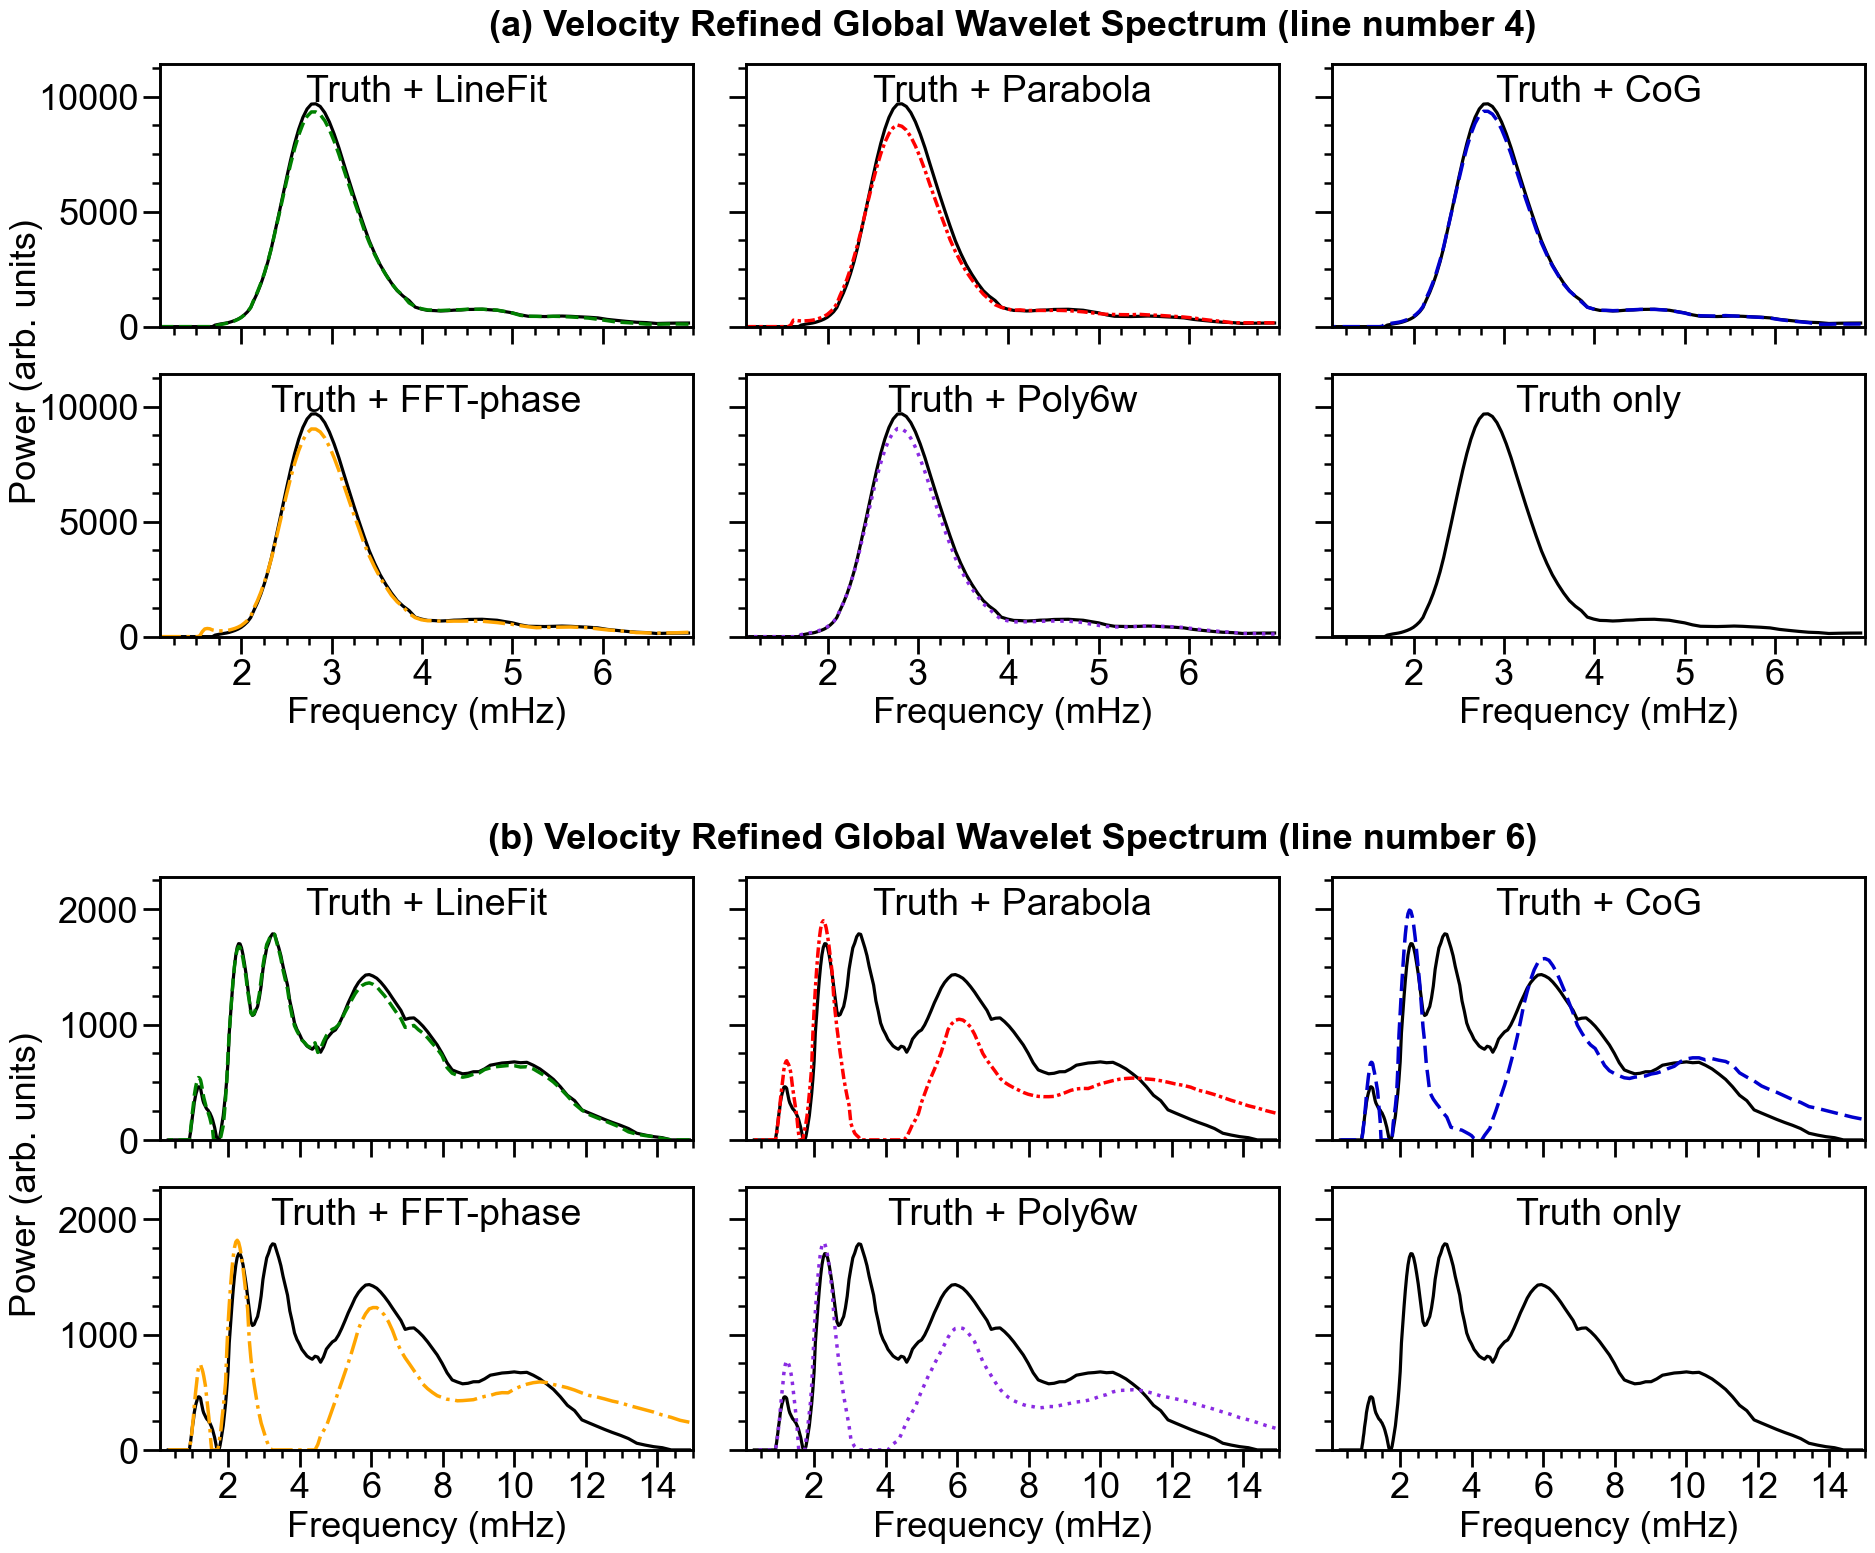

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/Figure4_power_spectra_comparison.pdf'
Plotted Figure-4 from cache:
   Files/Fig4_cache/fig4_waveletGWS_multiline__line3
   Files/Fig4_cache/fig4_waveletGWS_multiline__line5
RUN_LINEFIT_TIMESERIES: True | APOD: 0.1


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure 4 — Plot (RGWS small multiples, from cache)
===================================================

Purpose
-------
Generate the *paper Figure 4* from the precomputed Figure-4 cache produced by
"Figure 4 — Calculations". The figure is rendered as two stacked blocks:

  (a) Line index LINE_TOP
  (b) Line index LINE_BOTTOM

Each block is a 2×3 grid of panels:

    [Truth + LineFit]   [Truth + Parabola]   [Truth + CoG]
    [Truth + FFT-phase] [Truth + Poly6w]     [Truth only]

Inputs
------
Reads cache files from:
  Files/Fig4_cache/

Each requested line uses:
  fig4_waveletGWS_multiline__line{idx}__f_mhz.npy
  fig4_waveletGWS_multiline__line{idx}__P_truth.npy
  fig4_waveletGWS_multiline__line{idx}__P_linefit.npy
  fig4_waveletGWS_multiline__line{idx}__P_parab.npy
  fig4_waveletGWS_multiline__line{idx}__P_cog.npy
  fig4_waveletGWS_multiline__line{idx}__P_fft.npy
  fig4_waveletGWS_multiline__line{idx}__P_poly.npy
  fig4_waveletGWS_multiline__line{idx}__meta.npz

Important: No changes to plot results/styles
--------------------------------------------
Only *necessary* updates are made for:
  • directory structure: Files/Fig4_cache/
  • naming consistency: "LineFit" (not "WaLSA") and P_linefit (not P_walsa)
  • meta flag: RUN_LINEFIT_TIMESERIES (backwards compatible)

Dependencies
------------
numpy, matplotlib
WaLSAtools (WaLSA_save_pdf)

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

from __future__ import annotations

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

from WaLSAtools import WaLSA_save_pdf  # type: ignore


# =============================================================================
# USER SETTINGS
# =============================================================================

FIG4_CACHE_DIR = "Files/Fig4_cache"
FIG4_CACHE_TAG = "fig4_waveletGWS_multiline"

# 0-based line indices (must exist in cache)
LINE_TOP    = 3
LINE_BOTTOM = 5

# =============================================================================
# Style mapping (same as Fig. 2 / Fig. 3)
# =============================================================================
METHOD_STYLES = {
    "LineFit":   {"color": "green",      "linestyle": "--"},
    "Parabola":  {"color": "red",        "linestyle": (0, (3, 1, 1, 1))},
    "CoG":       {"color": "mediumblue", "linestyle": (0, (5, 2))},
    "FFT-phase": {"color": "orange",     "linestyle": "-."},
    "Poly6w":    {"color": "blueviolet", "linestyle": ":"},
    "Truth":     {"color": "black",      "linestyle": "-"},
}


# =============================================================================
# Loader helper
# =============================================================================
def load_line_cache(line_idx: int) -> dict:
    tag = f"{FIG4_CACHE_TAG}__line{int(line_idx)}"
    meta = np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__meta.npz"), allow_pickle=True)

    # Backwards-compatible meta flag handling
    if "RUN_LINEFIT_TIMESERIES" in meta.files:
        run_linefit = bool(meta["RUN_LINEFIT_TIMESERIES"])
    elif "RUN_WALSA_TIMESERIES" in meta.files:
        run_linefit = bool(meta["RUN_WALSA_TIMESERIES"])
    else:
        run_linefit = True

    return {
        "f_mhz":     np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__f_mhz.npy")),
        "P_truth":   np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__P_truth.npy")),
        "P_linefit": np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__P_linefit.npy")),
        "P_parab":   np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__P_parab.npy")),
        "P_cog":     np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__P_cog.npy")),
        "P_fft":     np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__P_fft.npy")),
        "P_poly":    np.load(os.path.join(FIG4_CACHE_DIR, f"{tag}__P_poly.npy")),
        "meta":      meta,
        "RUN_LINEFIT_TIMESERIES": run_linefit,
        "tag":       tag,
    }


top = load_line_cache(LINE_TOP)
bot = load_line_cache(LINE_BOTTOM)

# For consistency, use the flag from the top line meta (should match for both)
RUN_LINEFIT_TIMESERIES = bool(top["RUN_LINEFIT_TIMESERIES"])
APOD = float(top["meta"]["APOD"]) if "APOD" in top["meta"].files else np.nan


# =============================================================================
# Global plot style
# =============================================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "font.size": 27,
    "axes.titlesize": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 24,
    "figure.titlesize": 27,
    "axes.grid": False,
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "font.weight": 500,
    "axes.titleweight": 500,
    "axes.labelweight": 500,
})

plt.rc("axes", linewidth=2.1)
plt.rc("lines", linewidth=1.8)


# =============================================================================
# Figure layout: 2 outer rows, each a 2×3 grid
# =============================================================================
fig = plt.figure(figsize=(22, 18))
gs_outer = fig.add_gridspec(2, 1, hspace=0.42)


def make_power_row(subspec, data, line_idx, row_title, fmin_mhz, fmax_mhz, f1, f2, fint):
    """
    Render one 2×3 block of RGWS panels for a given line index.
    Plot is in frequency space (mHz).
    """
    subgs = subspec.subgridspec(2, 3, wspace=0.10, hspace=0.18)

    f = np.asarray(data["f_mhz"], float)
    m = np.isfinite(f) & (f >= float(fmin_mhz)) & (f <= float(fmax_mhz))

    panels = [
        ("Truth + LineFit",   "LineFit",   data["P_linefit"] if RUN_LINEFIT_TIMESERIES else None),
        ("Truth + Parabola",  "Parabola",  data["P_parab"]),
        ("Truth + CoG",       "CoG",       data["P_cog"]),
        ("Truth + FFT-phase", "FFT-phase", data["P_fft"]),
        ("Truth + Poly6w",    "Poly6w",    data["P_poly"]),
        ("Truth only",        None,        None),
    ]

    # Determine y-limits from the data shown (robust percentiles)
    y_all = [np.asarray(data["P_truth"], float)[m]]
    if RUN_LINEFIT_TIMESERIES:
        y_all.append(np.asarray(data["P_linefit"], float)[m])
    y_all += [
        np.asarray(data["P_parab"], float)[m],
        np.asarray(data["P_cog"],   float)[m],
        np.asarray(data["P_fft"],   float)[m],
        np.asarray(data["P_poly"],  float)[m],
    ]
    y_all = np.concatenate([yy[np.isfinite(yy)] for yy in y_all if yy is not None])

    if y_all.size > 0:
        ylo, yhi = np.nanpercentile(y_all, [1, 99.5])
        pad = 0.08 * (yhi - ylo) if yhi > ylo else 1.0
        ylim = (max(0.0, ylo - pad), yhi + pad)
    else:
        ylim = (0.0, 1.0)

    # extra headroom for inside titles
    yr = ylim[1] - ylim[0]
    ylim = (ylim[0], ylim[1] + 0.12 * yr)

    axes = []
    for j, (title, method_name, y_method) in enumerate(panels):
        r = j // 3
        c = j % 3

        ax = fig.add_subplot(subgs[r, c])
        axes.append(ax)

        # Truth
        ax.plot(
            f[m], np.asarray(data["P_truth"], float)[m],
            color=METHOD_STYLES["Truth"]["color"],
            linestyle=METHOD_STYLES["Truth"]["linestyle"],
            lw=2.3,
        )

        # Method curve
        if method_name is not None:
            if (method_name == "LineFit") and (not RUN_LINEFIT_TIMESERIES or y_method is None):
                ax.text(0.04, 0.84, "LineFit not\ncomputed", transform=ax.transAxes)
            else:
                ax.plot(
                    f[m], np.asarray(y_method, float)[m],
                    color=METHOD_STYLES[method_name]["color"],
                    linestyle=METHOD_STYLES[method_name]["linestyle"],
                    lw=2.5,
                )

        ax.set_ylim(*ylim)
        ax.set_xlim(float(fmin_mhz), float(fmax_mhz))
        ax.set_xticks(np.arange(f1, f2, fint))

        # subpanel title inside plot
        ax.text(
            0.5, 0.96, title,
            transform=ax.transAxes,
            ha="center", va="top",
        )

        ax.tick_params(axis="both", which="major", length=12, width=2.0)
        ax.tick_params(axis="both", which="minor", length=6, width=1.8)
        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))

        # y tick labels only on left column
        if c != 0:
            ax.set_yticklabels([])

        # one shared-looking y-label for the whole 2×3 block
        if r == 1 and c == 0:
            ax.set_ylabel("Power (arb. units)")
            ax.yaxis.set_label_coords(-0.22, 1.05)

        # x labels only on bottom row
        if r == 1:
            ax.set_xlabel("Frequency (mHz)")
        else:
            ax.set_xticklabels([])

    # centered row title above block
    row_bbox_left  = axes[0].get_position()
    row_bbox_right = axes[2].get_position()
    x_center = 0.5 * (row_bbox_left.x0 + row_bbox_right.x1)
    y_top = row_bbox_left.y1 + 0.012

    fig.text(
        x_center, y_top,
        row_title + f" (line number {int(line_idx) + 1})",
        ha="center", va="bottom", fontsize=26, fontweight="bold",
    )

# -----------------------------------------------------------------------------
# Build the two blocks of panels for the two selected lines.
# -----------------------------------------------------------------------------
make_power_row(
    gs_outer[0], top, LINE_TOP,
    "(a) Velocity Refined Global Wavelet Spectrum",
    1.1, 7.0,
    2, 7, 1,
)
make_power_row(
    gs_outer[1], bot, LINE_BOTTOM,
    "(b) Velocity Refined Global Wavelet Spectrum",
    0.1, 15.0,
    2, 15, 2,
)

plt.show()

# Save the figure as a single PDF (paper output)
pdf_path = "Figures/Figure4_power_spectra_comparison.pdf"
WaLSA_save_pdf(fig, pdf_path, color_mode="CMYK", dpi=300, bbox_inches="tight", pad_inches=0.1)

print("Plotted Figure-4 from cache:")
print("  ", os.path.join(FIG4_CACHE_DIR, top["tag"]))
print("  ", os.path.join(FIG4_CACHE_DIR, bot["tag"]))
print("RUN_LINEFIT_TIMESERIES:", RUN_LINEFIT_TIMESERIES, "| APOD:", APOD)